In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


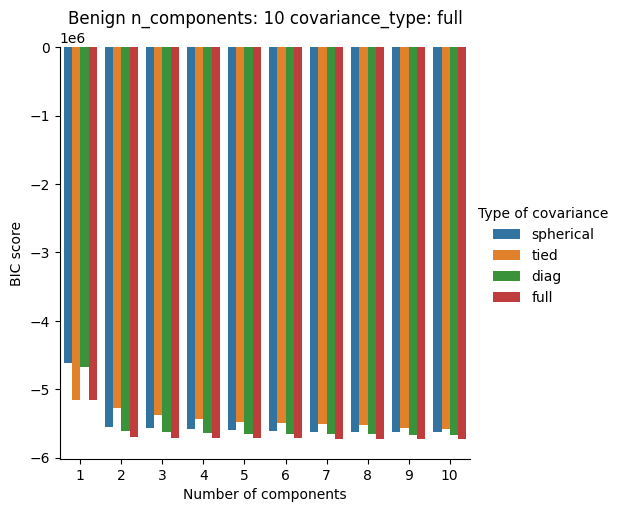

Tipo: 2 = DoS
Melhor modelo: n_componentes: 7 covariance_type: full


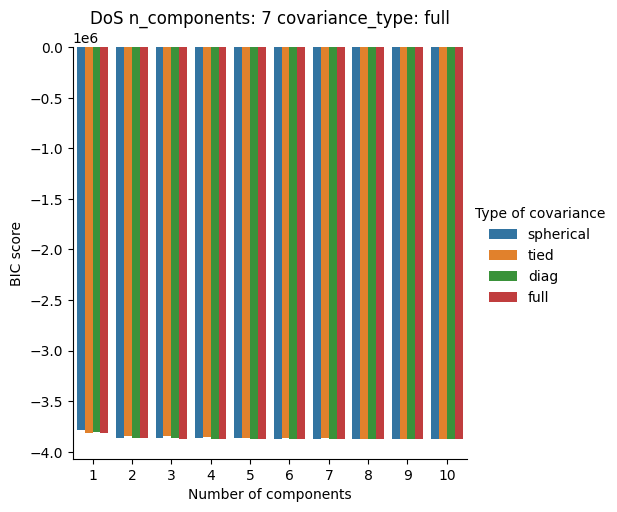

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 9 covariance_type: tied


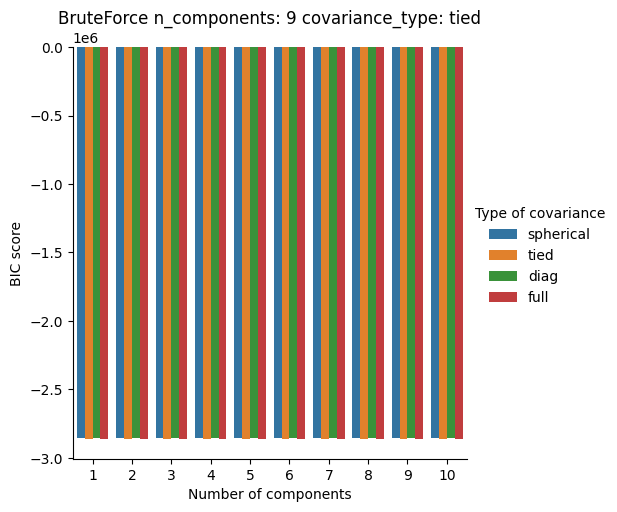

Tipo: 4 = Bot
Melhor modelo: n_componentes: 9 covariance_type: full


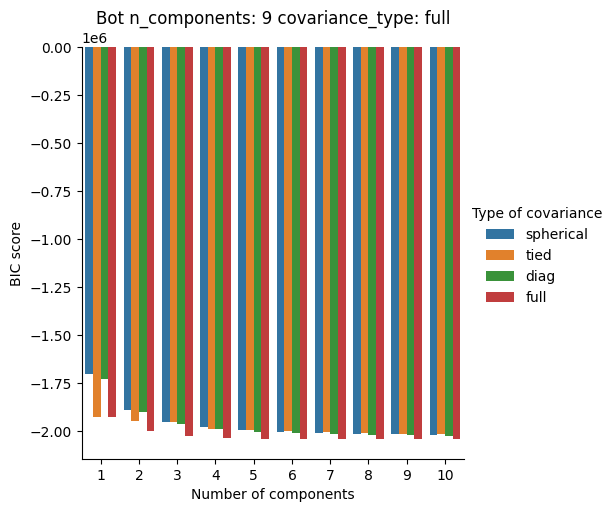

Tipo: 5 = Web
Melhor modelo: n_componentes: 6 covariance_type: full


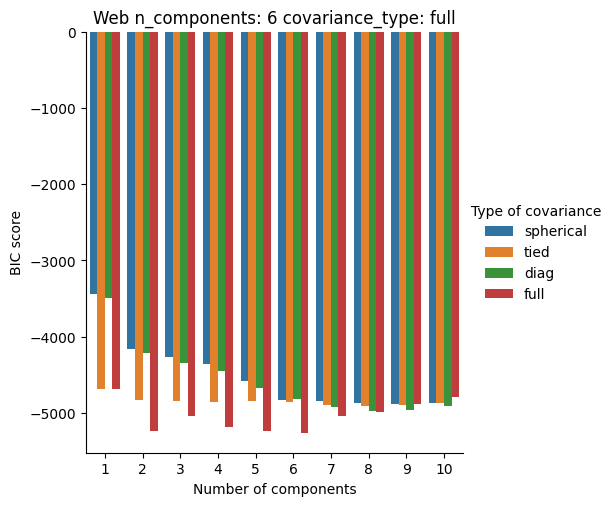

,0,1,2,3,4,5
0,NaN,25.826381,-75.558185,-390.587948,17.396015,18.626948
1,NaN,13.355900,29.716732,-182.675278,-71.357182,-5.895268
2,NaN,28.787423,-90.017173,-491.238973,12.766999,18.332457
3,NaN,11.817984,-87.981286,29.454480,-389.768411,-770.157361
4,NaN,28.773139,-84.185369,-464.720100,13.838500,18.544000
...,...,...,...,...,...,...
519951,NaN,28.262212,-99.377453,-526.864829,8.903794,18.344159
519952,NaN,17.354846,-250.481378,-731.469318,28.927080,23.390192
519953,NaN,9.026811,-112.417412,-326.809232,-1.148123,14.282582
519954,NaN,28.583223,-95.227522,-513.944897,9.137950,18.342875


,0,1,2,3,4,5
0,NaN,9.543507,-114.814606,-339.087178,7.574233,16.622405
1,NaN,24.969612,-74.624954,-383.651414,17.998807,18.626816
2,NaN,28.035056,-79.945384,-447.292256,15.720990,18.195246
3,NaN,25.847412,-99.382709,-500.311041,9.616882,18.892051
4,NaN,16.339283,-147.298778,-711.398828,2.978558,17.244697
...,...,...,...,...,...,...
649942,NaN,28.751102,-83.484924,-459.558983,14.178285,18.598597
649943,NaN,18.678342,-115.926979,-591.648147,4.957817,18.316975
649944,NaN,17.818715,-126.738923,-633.688353,4.313432,17.984813
649945,NaN,11.859480,-85.117616,29.539155,-382.326408,-755.451809


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 8 covariance_type: full


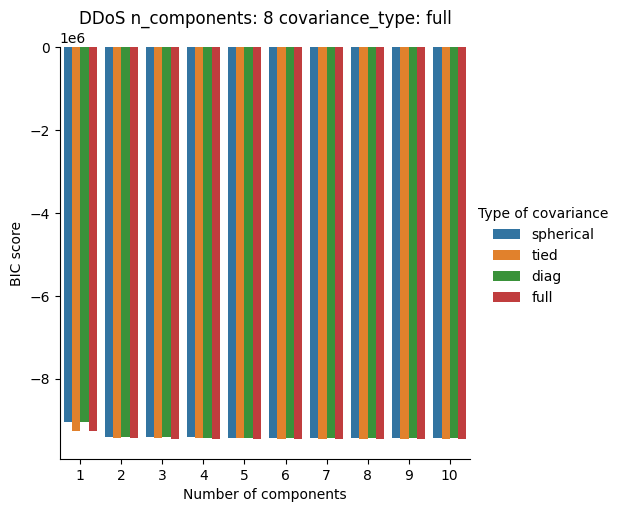

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


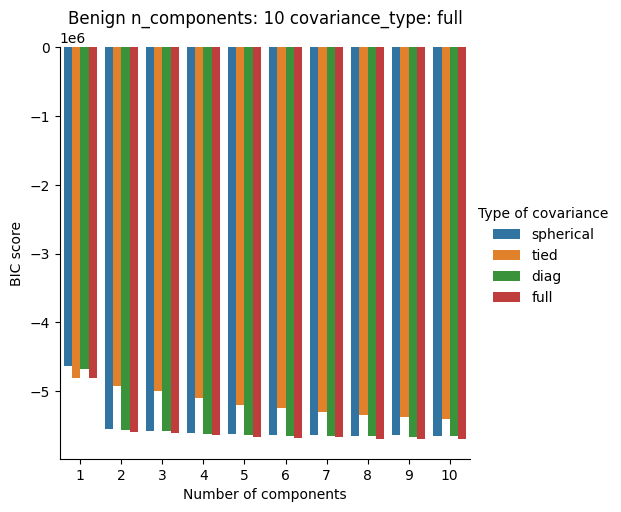

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: tied


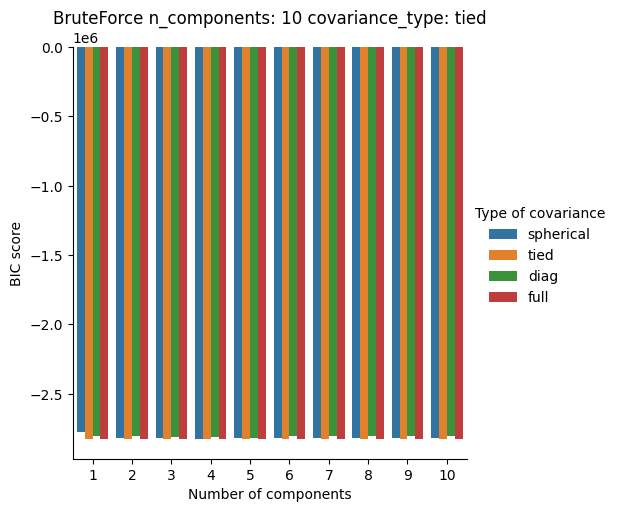

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


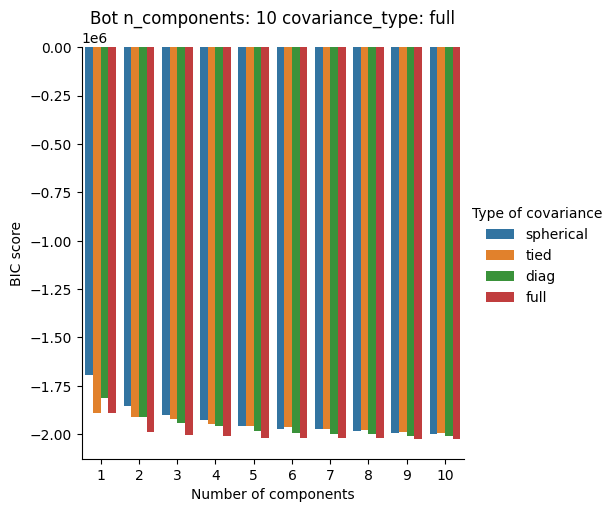

Tipo: 5 = Web
Melhor modelo: n_componentes: 8 covariance_type: diag


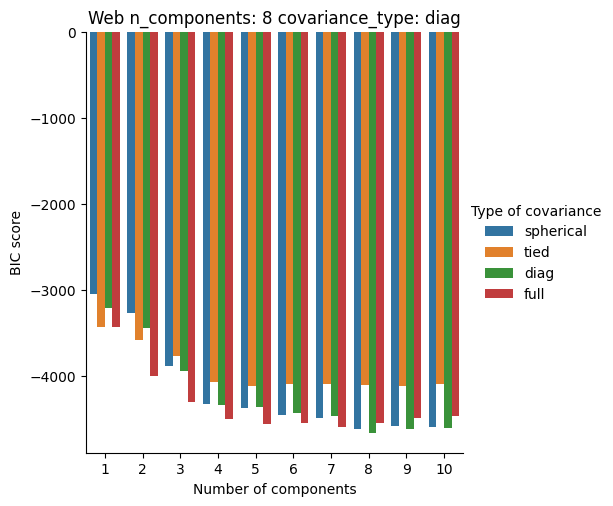

,0,1,2,3,4,5
0,29.457159,20.815930,NaN,-515.241817,7.083579,18.669193
1,-57.293971,18.221487,NaN,16.975310,5.825935,5.809005
2,-5.736095,28.628084,NaN,-2.527548,15.354303,7.595344
3,-803.070004,-28.396830,NaN,29.247389,-450.120754,-11.189762
4,4.954512,28.801462,NaN,-4.318400,15.513367,8.003991
...,...,...,...,...,...,...
519951,3.193279,28.519389,NaN,-3.458404,15.234573,5.877699
519952,-844.617037,16.629290,NaN,-1100.913471,28.825175,17.105638
519953,29.420837,20.547264,NaN,-533.908146,7.205945,17.918512
519954,2.558448,28.825766,NaN,-0.290578,15.407669,6.621804


,0,1,2,3,4,5
0,29.503395,20.786731,NaN,-529.580478,7.263038,18.181512
1,29.494509,20.907230,NaN,-518.008567,7.126003,18.649000
2,8.557638,28.158357,NaN,-8.743619,15.448823,5.599434
3,-10.158727,26.186266,NaN,-17.101945,15.392868,9.512198
4,29.079110,21.241307,NaN,-499.019078,7.421761,19.296142
...,...,...,...,...,...,...
649942,4.822289,28.774006,NaN,-4.088498,15.476679,8.028624
649943,29.089519,21.527495,NaN,-499.698994,7.614333,19.362706
649944,29.069081,21.480984,NaN,-499.760898,7.608419,19.378528
649945,-828.242566,-29.375818,NaN,29.353920,-464.364204,-11.910014


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


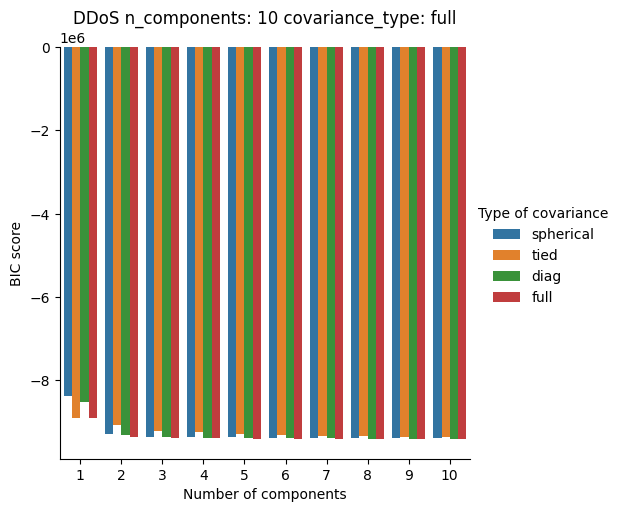

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


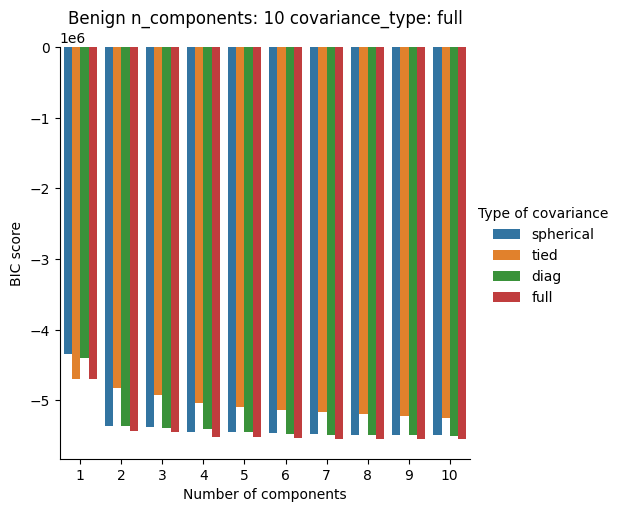

Tipo: 2 = DoS
Melhor modelo: n_componentes: 9 covariance_type: full


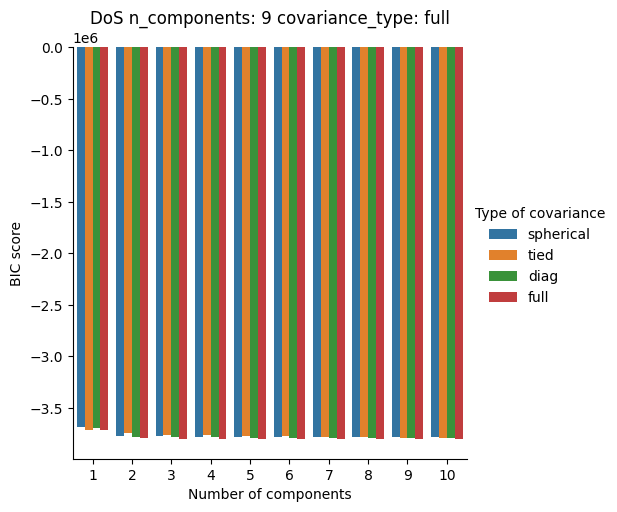

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


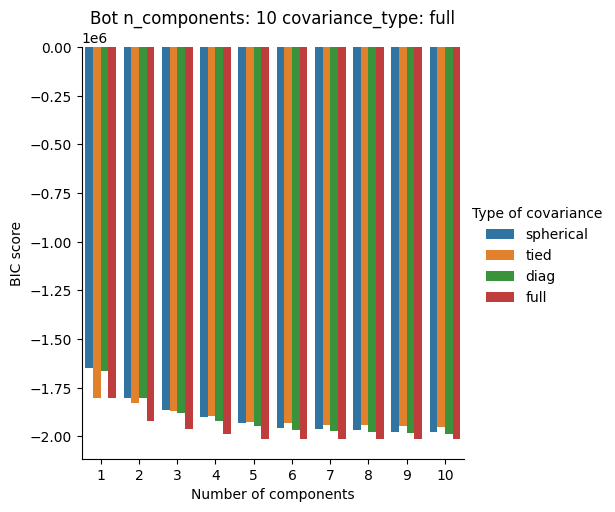

Tipo: 5 = Web
Melhor modelo: n_componentes: 5 covariance_type: full


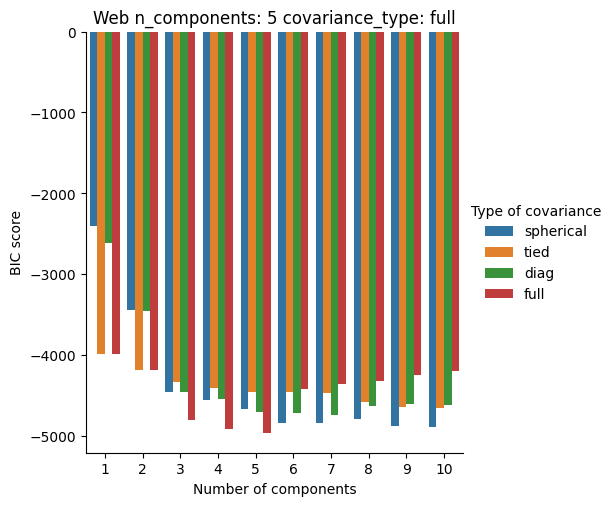

,0,1,2,3,4,5
0,29.260040,7.681073,-66.772212,NaN,7.738303,7.512611
1,-785.946945,12.410342,29.400354,NaN,-292.774117,7.766478
2,3.675490,28.191834,-40.396942,NaN,13.121742,14.683837
3,-630.608828,12.122165,12.161920,NaN,-225.482145,8.491063
4,5.496715,28.172494,-33.707982,NaN,15.099911,14.497057
...,...,...,...,...,...,...
519951,3.138292,28.383988,-38.240610,NaN,14.936281,14.626360
519952,3.066882,13.518324,-128.889072,NaN,28.680062,19.798938
519953,29.523879,10.517186,-65.392960,NaN,8.345261,8.125549
519954,7.692690,27.995624,-37.460329,NaN,13.457402,14.753574


,0,1,2,3,4,5
0,29.484797,10.421918,-65.164745,NaN,8.344482,8.166049
1,29.207088,7.626907,-66.917008,NaN,7.759627,7.484420
2,8.867670,26.317453,-43.323022,NaN,12.092935,14.663471
3,-10.364160,16.791102,-57.883505,NaN,6.968346,12.392883
4,28.927734,11.303867,-65.136472,NaN,8.394925,8.235893
...,...,...,...,...,...,...
649942,7.065984,28.367817,-33.369787,NaN,15.106821,14.555976
649943,29.157289,12.041366,-64.855181,NaN,8.386415,8.132474
649944,29.293251,11.403112,-65.404563,NaN,8.336579,8.082999
649945,-1310.576842,-71.692678,-335.311785,NaN,-1206.927914,-66.654514


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 9 covariance_type: full


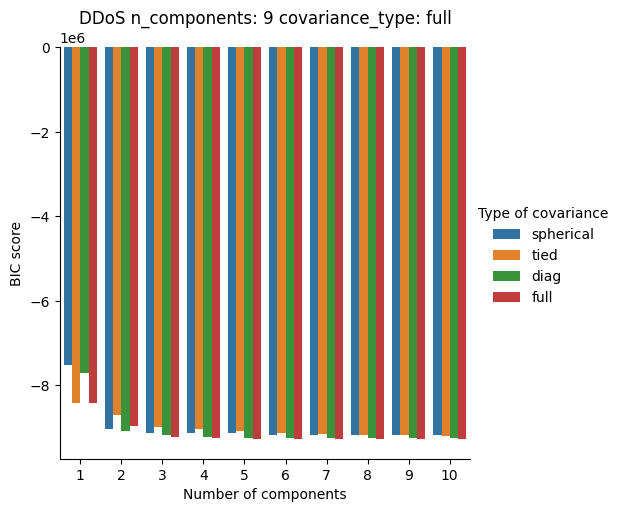

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


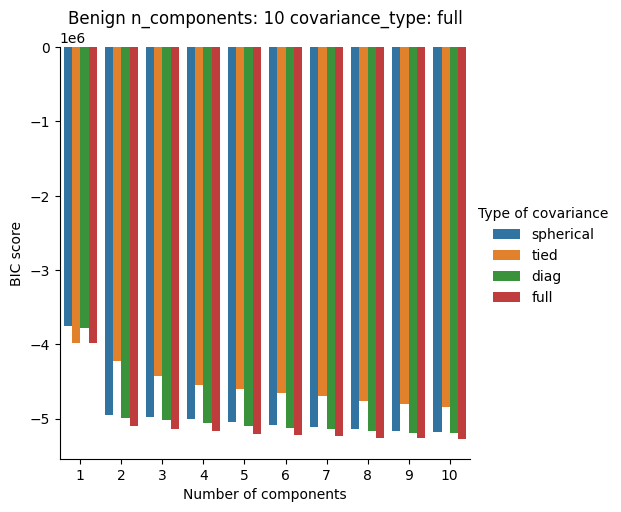

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


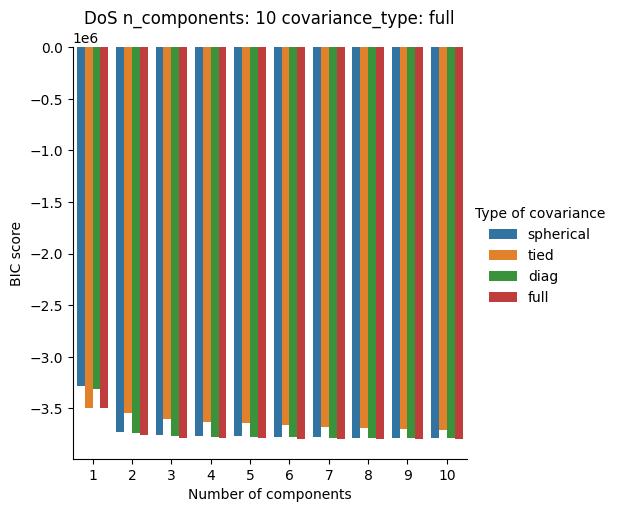

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 5 covariance_type: full


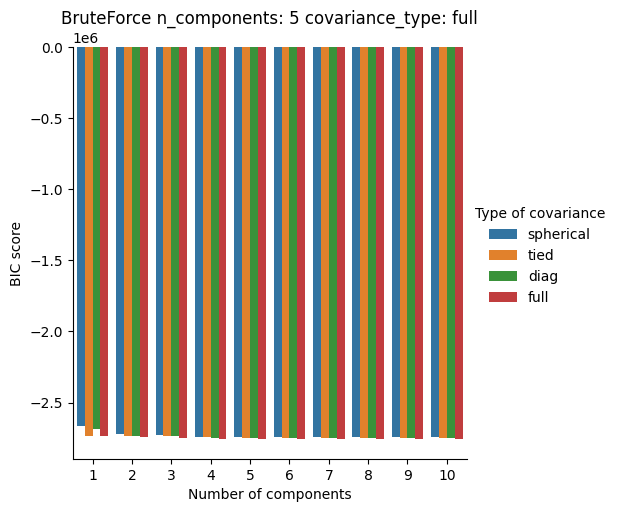

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: spherical


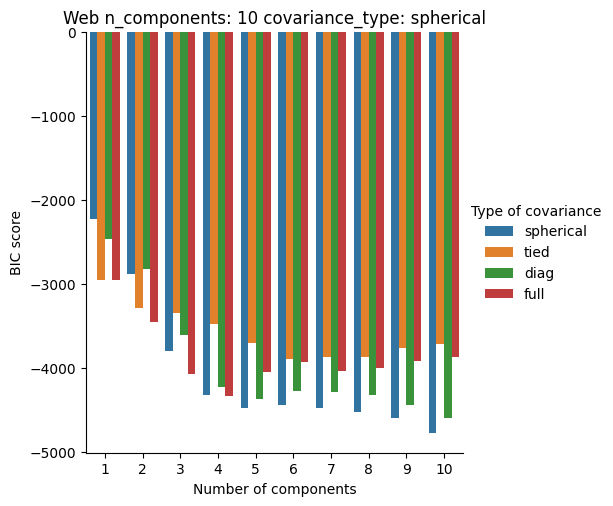

,0,1,2,3,4,5
0,28.863315,6.204187,-100.996415,-3472.214740,NaN,3.839917
1,-585.285854,7.487006,29.684761,-522.152561,NaN,-20.997422
2,12.898728,26.823571,-4.167681,-2035.681732,NaN,6.624988
3,-532.095241,2.279523,-10.734257,28.442986,NaN,-21.661556
4,7.245783,27.533511,-3.802426,-1919.563045,NaN,7.494364
...,...,...,...,...,...,...
519951,4.873757,25.896592,-3.495537,-1859.383013,NaN,8.007367
519952,5.670043,23.709983,-2.461552,-1787.990062,NaN,7.845973
519953,29.086515,6.098776,-104.268930,-3581.399503,NaN,3.698144
519954,16.862271,27.520853,-3.850287,-2018.359274,NaN,7.048888


,0,1,2,3,4,5
0,29.134107,6.116650,-104.307703,-3576.034233,NaN,3.739481
1,28.965856,6.193447,-100.914386,-3476.815197,NaN,3.828441
2,0.903177,20.929742,-1.513175,-1765.220305,NaN,6.731670
3,-35.596328,17.491242,-2.811171,-1557.071409,NaN,8.935447
4,29.045533,5.975173,-102.105683,-3495.380438,NaN,3.666471
...,...,...,...,...,...,...
649942,10.176851,27.762697,-3.826064,-1959.735367,NaN,7.238973
649943,28.862943,6.066677,-100.723552,-3500.359808,NaN,3.765314
649944,29.061545,5.977553,-102.182722,-3509.044126,NaN,3.686584
649945,-540.762836,2.263597,-11.084859,28.797047,NaN,-22.244689


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 9 covariance_type: full


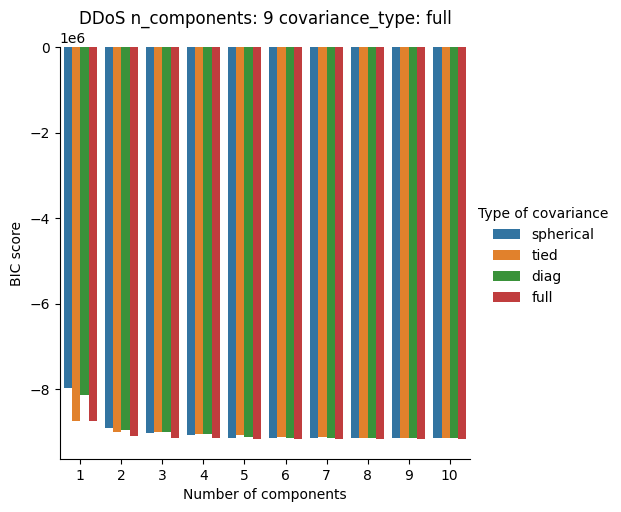

Tipo: 1 = Benign
Melhor modelo: n_componentes: 9 covariance_type: full


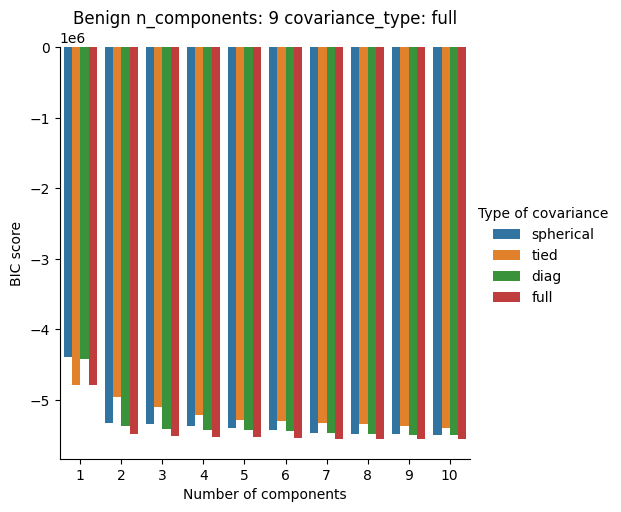

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


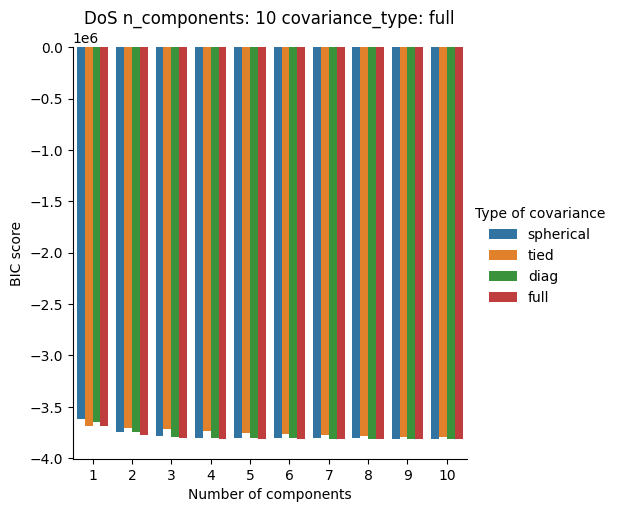

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 6 covariance_type: full


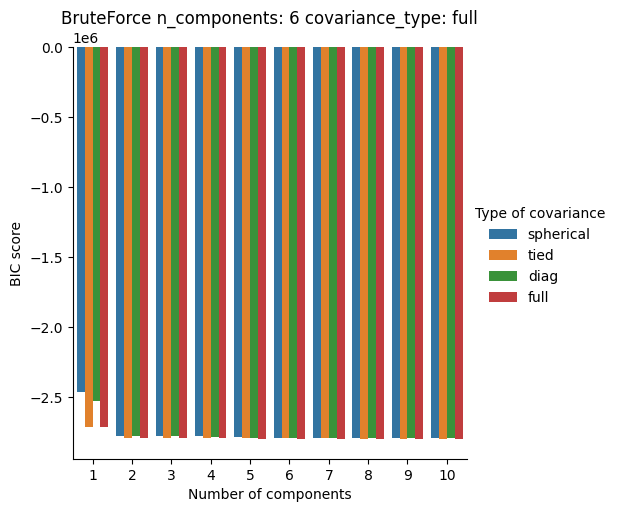

Tipo: 4 = Bot
Melhor modelo: n_componentes: 7 covariance_type: full


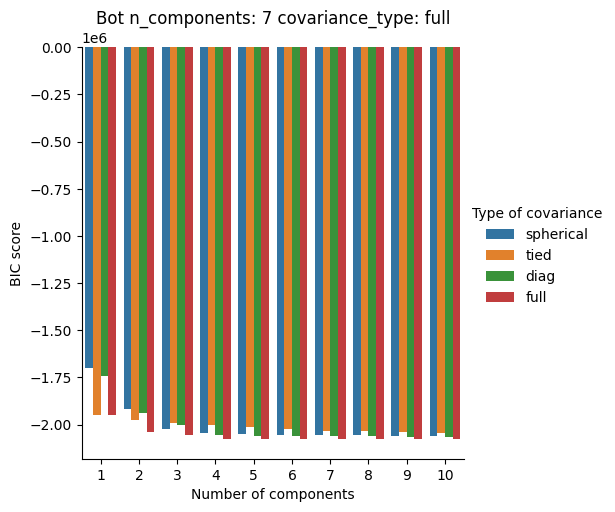

,0,1,2,3,4,5
0,28.257918,11.169021,-457.253883,-1740.904558,12.452085,NaN
1,-1242.887955,12.682511,29.533697,-59.931574,-71.844560,NaN
2,5.276570,27.525041,-12.633060,-309.896779,17.462202,NaN
3,-420.767666,11.722286,-36.934735,28.602019,-1115.626457,NaN
4,10.531648,28.244410,-14.154916,-345.459244,15.568032,NaN
...,...,...,...,...,...,...
519951,8.581613,28.117923,-11.900571,-327.485690,15.982819,NaN
519952,-163.943804,16.609851,-204.299058,-1135.635924,29.073636,NaN
519953,28.886208,20.188415,-436.193774,-1615.031272,14.743722,NaN
519954,11.126258,28.041468,-16.203338,-327.821222,15.783658,NaN


,0,1,2,3,4,5
0,28.882299,20.799260,-437.304678,-1596.452126,14.711070,NaN
1,28.086632,10.173096,-460.145397,-1745.373774,11.744828,NaN
2,13.362229,27.024477,-14.277525,-316.851082,16.868733,NaN
3,-5.856415,25.219875,-12.220071,-293.159919,17.720884,NaN
4,28.889995,19.039229,-433.994187,-1615.631256,14.111690,NaN
...,...,...,...,...,...,...
649942,10.662708,28.344582,-13.830501,-341.886511,15.678319,NaN
649943,28.832288,17.598729,-438.814945,-1627.510783,13.535658,NaN
649944,28.829779,17.992266,-439.023668,-1619.143940,13.625776,NaN
649945,-441.901232,11.791508,-40.388654,28.954303,-1139.790483,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)